<a href="https://colab.research.google.com/github/bigdata1210/Proyecto-Experimental-Big-Data/blob/main/Comparaci%C3%B3n_de_Modelos_y_Optimizaci%C3%B3n_de_Pipeline_%E2%80%94_Dataset_Titanic_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Comparación de Modelos y Optimización de Pipeline - Dataset Titanic
### Trabajo de tutoría - Introducción a Machine Learning

---

**Integrantes y distribución de tareas**

| Integrante | Tareas realizadas |
|---|---|
| Pamela Mishell Arellano Suárez | Fases 1, 2 y 3 |
| Melany Dayanna Vera Soledispa  | Fases 4 y 5 |
| Roberto Carlos Goyes Caiza | Fases 6, 7 y 9 |
| Joan Paulho Navas Villón | Fases 8, 10 y 11 |



## Resumen de fases

| #  | Fase                         | Descripción                                         |
| -- | ---------------------------- | --------------------------------------------------- |
| 1  | Importación de librerías     | Carga todas las herramientas necesarias             |
| 2  | Carga de datos               | Lee archivos para entrenar     |
| 3  | Feature Engineering          | Crea variables nuevas          |
| 4  | Partición train/test interna | Divide los datos para entrenamiento y evaluación    |
| 5  | Pipeline de preprocesamiento | Encapsula imputación, escalado y encoding           |
| 6  | Definición de modelos        | Prepara los 4 algoritmos a comparar                 |
| 7  | Búsqueda de hiperparámetros  | GridSearchCV para RF y GB                           |
| 8  | Evaluación comparativa       | Tabla de métricas, ROC y matriz de confusión        |
| 9  | Análisis de overfitting      | Compara desempeño de entrenamiento y validación     |
| 10 | Importancia de variables     | Identifica las 10 variables más influyentes         |
| 11 | Predicciones finales         | Genera predicciones  |


---
## **FASE 1** - Importación de librerías



In [1]:
# -----------------------------------------------------------------
# Fase 1 - Importación de librerías del proyecto
#------------------------------------------------------------------
# ¿POR QUÉ ESTE BLOQUE?
# Python no tiene todo disponible de entrada: hay que "pedir prestadas"
# las herramientas que vamos a usar. Esto se hace con 'import'.
# Lo ponemos todo junto aquí arriba para que cuando alguien lea el
# notebook, sepa de un vistazo qué herramientas usa el proyecto.
#
# LIBRERÍAS USADAS:
# - pandas   : maneja tablas de datos (cargar CSV, filtrar columnas, etc.)
# - numpy    : operaciones matemáticas sobre arrays y matrices
# - matplotlib/seaborn : crear gráficos y visualizaciones
# - warnings : silenciar avisos técnicos de sklearn que no afectan resultados
#
# - sklearn (scikit-learn) — librería principal de Machine Learning:
#     train_test_split  : dividir datos en entrenamiento y prueba
#     GridSearchCV      : búsqueda sistemática de hiperparámetros
#     cross_val_score   : validación cruzada para medir overfitting
#     Pipeline          : encadenar preprocesamiento + modelo en un solo paso
#     ColumnTransformer : aplicar transformaciones distintas por tipo de columna
#     SimpleImputer     : rellenar valores faltantes (NaN)
#     StandardScaler    : escalar variables numéricas a media 0 y desv. estándar 1
#     OneHotEncoder     : convertir categorías de texto a columnas numéricas binarias
#     DecisionTreeClassifier    : modelo Árbol de Decisión
#     RandomForestClassifier    : modelo Random Forest (ensamble de árboles)
#     GradientBoostingClassifier: modelo Gradient Boosting (ensamble secuencial)
#     LogisticRegression        : modelo Regresión Logística (lineal)
#     permutation_importance    : medir importancia de variables para cualquier modelo
#     métricas: accuracy, precisión, recall, F1, AUC-ROC, matriz de confusión, curva ROC
# ---------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ----------------------------------------------------------------------
# CONSTANTE GLOBAL: semilla aleatoria
# ¿POR QUÉ? Muchos algoritmos (Random Forest, splits, etc.) usan
# números aleatorios. Si no fijamos la semilla, cada vez que corremos
# el notebook los resultados cambian un poco. Con random_state=42
# garantizamos que los resultados son siempre los mismos (reproducibilidad).
# Esto también es importante para que el profesor pueda correr nuestro
# notebook y obtener exactamente los mismos números que nosotros.
# ----------------------------------------------------------------------
RANDOM_STATE = 42

sns.set_style("whitegrid")
print("Todas las librerías importadas correctamente.")


Todas las librerías importadas correctamente.


---
## **FASE 2** - Carga de datos

> ⚠️ **Antes de ejecutar esta fase**: asegurate de tener los archivos cargados
> (ícono de carpeta a la izquierda → "Subir al almacenamiento de la sesión")


In [2]:
# --------------------------------------------------------------------
# Fase 2 - Carga de archivos
#
# ¿QUÉ HACE ESTE BLOQUE?
# Lee el archivo train.csv que el profesor nos dio y lo carga en una
# variable llamada 'df' (abreviación de DataFrame, que es como se llama
# a una tabla de datos en pandas)
#--------------------------------------------------------------------


df = pd.read_csv("train.csv")

print(f"Filas (pasajeros): {df.shape[0]}")
print(f"Columnas (variables): {df.shape[1]}")
print(f"Columnas disponibles: {df.columns.tolist()}")


Filas (pasajeros): 891
Columnas (variables): 12
Columnas disponibles: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [3]:
# --------------------------------------------------------------------
# Primeras filas del dataset
#
# ¿QUÉ HACE ESTE BLOQUE?
# Muestra las primeras 5 filas del dataset para que podamos ver
# cómo lucen los datos: qué columnas hay, qué tipo de valores tienen,
# si hay celdas vacías a simple vista, etc.
# --------------------------------------------------------------------

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# --------------------------------------------------------------------
# Revisión de valores faltantes (NaN)
#
# ¿QUÉ HACE ESTE BLOQUE?
# Cuenta cuántos valores faltan (celdas vacías) en cada columna.
# Esto es importante porque:
# 1. Los modelos de Machine Learning NO pueden trabajar con NaN:
#    si dejamos valores faltantes, el código va a dar error.
# 2. Nos ayuda a decidir qué estrategia de imputación usar después
#    en el Pipeline (Fase 5):
#    - Age: faltan ~177 valores → imputamos con la mediana
#    - Cabin: faltan ~687 valores (la mayoría) → no intentamos imputar,
#      sino que lo convertimos en una variable binaria HasCabin (¿tiene cabina o no?)
#    - Embarked: solo 2 faltantes → imputamos con el valor más frecuente
# --------------------------------------------------------------------

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Faltantes': missing, '% del total': missing_pct})[missing > 0]


,Faltantes,% del total
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


---
##  **FASE 3** - Feature Engineering

El **feature engineering** (ingeniería de características) es el proceso de crear variables nuevas a partir de
las que ya existen en el dataset, con el objetivo de darle al modelo información más útil o en un formato más
fácil de procesar. Es una de las etapas más importantes de cualquier proyecto de ML: un buen feature engineering
puede mejorar el desempeño del modelo mucho más que cambiar el algoritmo.

En esta fase creamos:
- **3 variables conocidas**: `Title`, `FamilySize`, `HasCabin`
- **2 variables nuevas**: `Fare_per_person`, `Is_alone`



In [5]:
# --------------------------------------------------------------------
# Fase 3 - Variable 'Title'
#
# ¿QUÉ HACE ESTE BLOQUE?
# Extrae el título de cada pasajero a partir del campo 'Name'.
# El nombre en el dataset siempre tiene este formato:
#   "Braund, Mr. Owen Harris"  →  título = "Mr"
#   "Heikkinen, Miss. Laina"   →  título = "Miss"

# ¿POR QUÉ ES ÚTIL?
# El título codifica el género:
#   - "Mrs" / "Miss" → mujeres (mayor supervivencia)
#   - "Master" → niños varones (mayor supervivencia)
#   - "Mr" → hombres adultos (menor supervivencia)
# Es mucho más específico que la columna 'Sex' sola, porque distingue
# niños de adultos dentro del grupo masculino.
#
# Luego agrupamos títulos poco frecuentes en "Rare" para evitar que
# el modelo tenga categorías con 1-2 personas, que son demasiado
# específicas y no generalizan bien.
# --------------------------------------------------------------------

df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')

title_map = {
    'Mlle': 'Miss',       # Mlle es francés para Miss
    'Ms': 'Miss',         # Ms es equivalente a Miss/Mrs
    'Mme': 'Mrs',         # Mme es francés para Mrs
    'Lady': 'Rare',       # títulos nobiliarios o muy poco frecuentes
    'Countess': 'Rare',
    'Capt': 'Rare',
    'Col': 'Rare',
    'Don': 'Rare',
    'Dr': 'Rare',
    'Major': 'Rare',
    'Rev': 'Rare',
    'Sir': 'Rare',
    'Jonkheer': 'Rare',
    'Dona': 'Rare',
    'the Countess': 'Rare'
}
df['Title'] = df['Title'].replace(title_map)

print("Distribución de títulos después del mapeo:")
print(df['Title'].value_counts())


Distribución de títulos después del mapeo:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [6]:
# --------------------------------------------------------------------
# Variable "FamilySize"
#
# ¿QUÉ HACE ESTE BLOQUE?
# Crea una variable que representa el tamaño total del grupo familiar
# de cada pasajero a bordo del Titanic.
#
# El dataset ya tiene dos columnas relacionadas:
#   - SibSp: número de hermanos y cónyuge a bordo
#   - Parch: número de padres e hijos a bordo
# Sumando ambas y añadiendo 1 (el propio pasajero) obtenemos el
# tamaño total del grupo.
#
# ¿POR QUÉ ES ÚTIL?
# Familias muy grandes (5+) podían tener dificultades para evacuarse
# juntas y encontrar espacio en los botes. Familias pequeñas (2-4)
# quizás tuvieron más facilidad de moverse rápido.
# --------------------------------------------------------------------

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("Distribución de tamaño familiar:")
print(df['FamilySize'].value_counts().sort_index())


Distribución de tamaño familiar:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


In [7]:
# --------------------------------------------------------------------
# Variable 'HasCabin'
#
# ¿QUÉ HACE ESTE BLOQUE?
# Convierte la columna 'Cabin' (que tiene 687 valores faltantes de 891 posibles, o sea el 77% está vacío) en una variable binaria:
#   - 1 si el pasajero TIENE número de cabina registrado
#   - 0 si NO tiene (el valor era NaN/vacío)
#
# ¿POR QUÉ NO USAMOS LA COLUMNA 'Cabin' DIRECTAMENTE?
# Hay dos problemas: primero, el 77% de los valores son NaN,
# demasiados para imputar de forma confiable. Segundo, el número
# de cabina en sí no nos dice mucho, pero el HECHO de tener un
# número registrado sí: generalmente eran pasajeros de 1ra clase,
# lo que está correlacionado con mayor supervivencia.
# --------------------------------------------------------------------

df['HasCabin'] = df['Cabin'].notna().astype(int)

print("Pasajeros con cabina registrada:", df['HasCabin'].sum())
print("Pasajeros sin cabina registrada:", (df['HasCabin'] == 0).sum())


Pasajeros con cabina registrada: 204
Pasajeros sin cabina registrada: 687


In [8]:
# --------------------------------------------------------------------
# Variable NUEVA 1: "Fare_per_person"
#
# ¿QUÉ HACE ESTE BLOQUE?
# Crea una nueva variable dividiendo la tarifa (Fare) entre el tamaño
# del grupo familiar (FamilySize).
#
# JUSTIFICACIÓN:
# La columna 'Fare' en este dataset está registrada por boleto/grupo
# familiar, NO por persona individual. Varios miembros de una misma
# familia comparten el mismo número de ticket y, por lo tanto, el
# mismo valor de Fare total. Esto significa que una familia de 4
# personas de 1ra clase puede tener un Fare muy alto, pero no porque
# cada uno pagara mucho, sino porque son 4 personas. Dividir entre
# FamilySize nos da una aproximación del poder adquisitivo real de
# CADA pasajero, que es lo que realmente refleja su clase social
# y, en consecuencia, su probable posición en el barco y prioridad
# de evacuación.
# --------------------------------------------------------------------

df['Fare_per_person'] = df['Fare'] / df['FamilySize']

print("Primeros valores de Fare_per_person:")
print(df[['Fare', 'FamilySize', 'Fare_per_person']].head(8))


Primeros valores de Fare_per_person:
      Fare  FamilySize  Fare_per_person
0   7.2500           2          3.62500
1  71.2833           2         35.64165
2   7.9250           1          7.92500
3  53.1000           2         26.55000
4   8.0500           1          8.05000
5   8.4583           1          8.45830
6  51.8625           1         51.86250
7  21.0750           5          4.21500


In [9]:
# --------------------------------------------------------------------
# Variable NUEVA 2: "Is_alone"
# ¿QUÉ HACE ESTE BLOQUE?
# Crea una variable binaria que vale 1 si el pasajero viajaba SOLO
# (sin ningún familiar a bordo) y 0 si viajaba acompañado.
#
# JUSTIFICACIÓN:
# Viajar solo pudo afectar la supervivencia de forma distinta a viajar
# en grupo. Una persona sola no tenía que esperar ni buscar a familiares
# para evacuar, pero tampoco tenía quien le diera prioridad o ayuda al
# abordar un bote. Es un efecto que 'FamilySize' por sí sola no captura
# bien de forma lineal: el modelo podría no identificar automáticamente
# que "ser el único" (FamilySize == 1) tiene un comportamiento especial
# y diferente a "ser el menor de un grupo" (FamilySize == 2). Al crear
# esta variable binaria explícita, le facilitamos al modelo detectar ese
# efecto umbral sin necesidad de aprenderlo por cuenta propia.
# --------------------------------------------------------------------

df['Is_alone'] = (df['FamilySize'] == 1).astype(int)

print("Pasajeros que viajaban solos:", df['Is_alone'].sum())
print("Pasajeros que viajaban acompañados:", (df['Is_alone'] == 0).sum())


Pasajeros que viajaban solos: 537
Pasajeros que viajaban acompañados: 354


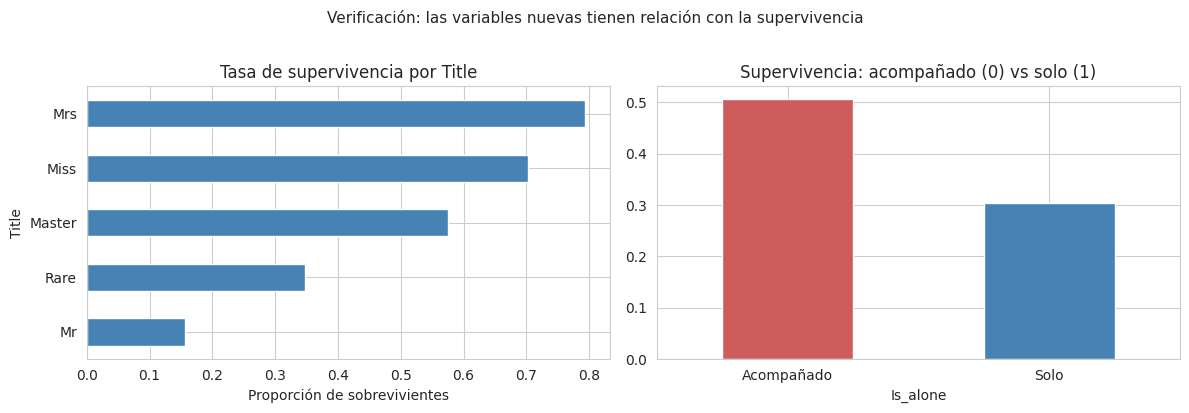

In [10]:
# --------------------------------------------------------------------
# Visualización: tasa de supervivencia por Title y por Is_alone
#
# ¿QUÉ HACE ESTE BLOQUE?
# Muestra dos gráficos de barras que confirman visualmente que las
# variables que creamos tienen relación con la supervivencia, es decir,
# que SÍ aportan información predictiva al modelo.
#
# Grafico izquierdo: tasa de supervivencia por título
# Confirma que 'Title' captura la distinción de género/edad:
# Miss/Mrs/Master tienen tasas mucho más altas que Mr.
#
# Gráfico derecho: tasa de supervivencia según viaje solo o acompañado
# Confirma que 'Is_alone' aporta señal: los pasajeros acompañados
# sobrevivieron en mayor proporción.
# --------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('Title')['Survived'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Tasa de supervivencia por Title')
axes[0].set_xlabel('Proporción de sobrevivientes')

df.groupby('Is_alone')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color=['indianred', 'steelblue']
)
axes[1].set_title('Supervivencia: acompañado (0) vs solo (1)')
axes[1].set_xticklabels(['Acompañado', 'Solo'], rotation=0)

plt.suptitle('Verificación: las variables nuevas tienen relación con la supervivencia',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


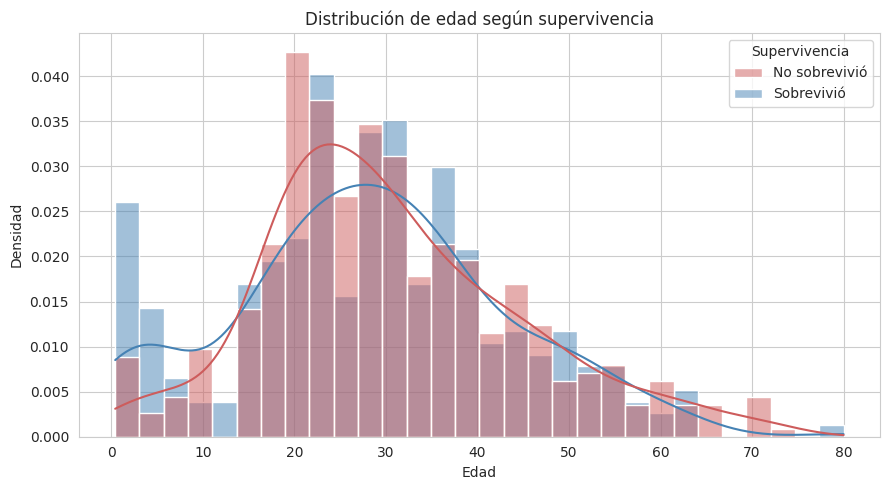

In [11]:
# --------------------------------------------------------------------
# Visualización: distribución de edad por supervivencia
#
# ¿QUÉ HACE ESTE BLOQUE?
# Muestra cómo se distribuye la edad entre los pasajeros que
# sobrevivieron vs los que no. Es un análisis exploratorio para
# entender mejor los datos antes de entrenar los modelos.
#
# Usamos 'stat=density' (en vez de conteo absoluto) para que las
# dos curvas sean comparables aunque haya más muertos que sobrevivientes.
# --------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df, x='Age', hue='Survived', kde=True, stat='density',
    common_norm=False, bins=30, palette={0: 'indianred', 1: 'steelblue'}, ax=ax
)
ax.set_title('Distribución de edad según supervivencia')
ax.set_xlabel('Edad')
ax.set_ylabel('Densidad')

legend = ax.get_legend()
legend.set_title('Supervivencia')
for text, label in zip(legend.get_texts(), ['No sobrevivió', 'Sobrevivió']):
    text.set_text(label)

plt.tight_layout()
plt.show()


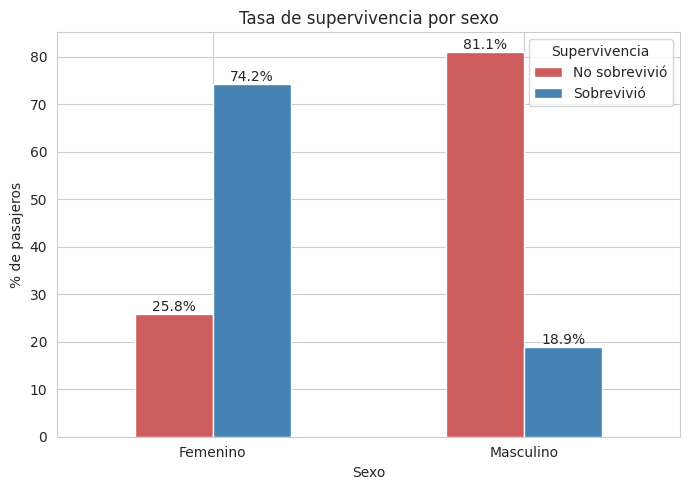

In [12]:
# --------------------------------------------------------------------
# Visualización: tasa de supervivencia por sexo
#
# ¿QUÉ HACE ESTE BLOQUE?
# Muestra la proporción de supervivencia por sexo, con barras
# apiladas que suman 100% para cada género (eje Y en porcentaje).
#
# pd.crosstab con normalize='index' divide cada fila entre su total,
# convirtiéndola en porcentajes que suman 100% por fila (por género).
# Multiplicamos x100 para pasar de fracciones (0.74) a porcentajes (74%).
# --------------------------------------------------------------------

survival_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
survival_sex.columns = ['No sobrevivió', 'Sobrevivió']
survival_sex.index = ['Femenino' if s == 'female' else 'Masculino' for s in survival_sex.index]

fig, ax = plt.subplots(figsize=(7, 5))
survival_sex.plot(kind='bar', ax=ax, color=['indianred', 'steelblue'])
ax.set_title('Tasa de supervivencia por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('% de pasajeros')
ax.set_xticklabels(survival_sex.index, rotation=0)
ax.legend(title='Supervivencia')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.show()


---
## **FASE 4** - División train/test

- **80% en entrenamiento** (`X_train`, `y_train`): los modelos aprenden con estos datos
- **20% en prueba interna** (`X_test`, `y_test`): evaluamos el desempeño de los modelos en datos no vistos



In [13]:
# --------------------------------------------------------------------
# Separar variables predictoras (X) y variable objetivo (y)
#
# ¿QUÉ HACE ESTE BLOQUE?
# Divide el DataFrame en:
#   - X: todas las columnas que el modelo usa como "pistas" para predecir
#   - y: la columna que queremos predecir ('Survived': 1=sobrevivió, 0=no)
#
# Elegimos solo las columnas que tienen sentido predictivo. Excluimos:
#   - PassengerId: solo un número de identificación, no aporta información
#   - Name: el nombre raw ya lo usamos para extraer Title
#   - Ticket: número de boleto, no tiene señal predictiva clara
#   - Cabin: ya la convertimos en HasCabin
# --------------------------------------------------------------------

numeric_features = [
    'Age',            # edad del pasajero
    'Fare',           # tarifa total pagada
    'Fare_per_person',# tarifa por persona (nueva)
    'Pclass',         # clase del boleto (1, 2, o 3)
    'SibSp',          # hermanos/cónyuge a bordo
    'Parch',          # padres/hijos a bordo
    'FamilySize'      # tamaño total del grupo familiar (de clase)
]

categorical_features = [
    'Sex',      # género del pasajero
    'Embarked', # puerto de embarque (C=Cherbourg, Q=Queenstown, S=Southampton)
    'Title',    # título extraído del nombre (de clase)
    'Is_alone', # 1=viajaba solo, 0=acompañado (nueva)
    'HasCabin'  # 1=tiene cabina registrada, 0=no (de clase)
]

X = df[numeric_features + categorical_features]
y = df['Survived']

print(f"Variables predictoras (X): {X.shape[1]} columnas, {X.shape[0]} filas")
print(f"Variable objetivo (y): {y.shape[0]} valores")
print(f"Distribución de y → sobrevivió: {y.mean():.1%} | no sobrevivió: {(1-y.mean()):.1%}")


Variables predictoras (X): 12 columnas, 891 filas
Variable objetivo (y): 891 valores
Distribución de y → sobrevivió: 38.4% | no sobrevivió: 61.6%


In [14]:
# --------------------------------------------------------------------
# División train/test con train_test_split
#
# ¿QUÉ HACE ESTE BLOQUE?
# Divide X e y en 4 partes:
#  - X_train, y_train: 80% de los datos → para ENTRENAR los modelos
#  - X_test, y_test: 20% de los datos → para EVALUAR los modelos al final
#
# PARÁMETROS IMPORTANTES:
# - test_size=0.2: reservamos el 20% para prueba (178 pasajeros aprox.)
# - stratify=y: garantiza que el 38% de sobrevivientes se mantiene en
#   ambas partes. Sin esto, podría pasar que el test tenga mucho más
#   (o mucho menos) del 38% por puro azar del split, haciendo la
#   evaluación poco representativa.
# - random_state=42: mismo split siempre (reproducibilidad).
#
# --------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape[0]} pasajeros ({X_train.shape[0]/len(X):.0%} del total)")
print(f"X_test:  {X_test.shape[0]} pasajeros ({X_test.shape[0]/len(X):.0%} del total)")
print(f"Sobrevivientes en train: {y_train.mean():.3f} | en test: {y_test.mean():.3f}")
print("✅ El balance de clases es similar en ambas particiones (gracias a stratify).")


X_train: 712 pasajeros (80% del total)
X_test:  179 pasajeros (20% del total)
Sobrevivientes en train: 0.383 | en test: 0.385
✅ El balance de clases es similar en ambas particiones (gracias a stratify).


---
## **FASE 5** - Pipeline de preprocesamiento


In [15]:
# --------------------------------------------------------------------
# Preprocesador para variables NUMÉRICAS
# ¿QUÉ HACE ESTE BLOQUE?
# Define cómo tratar las columnas numéricas (Age, Fare, Pclass, etc.):
#
# PASO 1 — SimpleImputer(strategy='median'):
#   Rellena los valores faltantes (NaN) con la MEDIANA de cada columna.
#   ¿Por qué mediana y no media?
#   Porque la mediana es robusta a valores extremos (outliers).
#   En 'Fare', hay pasajeros de 1ra clase con tarifas muy altas que
#   inflarían la media. La mediana, en cambio, no se ve afectada por esos extremos.
#
# PASO 2 — StandardScaler():
#   Escala las variables numéricas para que tengan media=0 y desv. estándar=1.
#   ¿Por qué es necesario?
#   Porque los modelos lineales (Regresión Logística) son sensibles a la
#   escala de las variables. Sin escalar, 'Fare' (valores ~0-500) dominaría
#   sobre 'Pclass' (valores 1-3), dándole un peso artificial por el tamaño
#   de sus números y no por su importancia real.
#   Los árboles (Decision Tree, Random Forest) no necesitan escalado, pero
#   tampoco les hace daño, así que lo dejamos para todos.
# --------------------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
print("✅ Transformador numérico definido: Imputación (mediana) + Escalado (StandardScaler)")


✅ Transformador numérico definido: Imputación (mediana) + Escalado (StandardScaler)


In [16]:
# --------------------------------------------------------------------
# Preprocesador para variables CATEGÓRICAS
#
# ¿QUÉ HACE ESTE BLOQUE?
# Define cómo tratar las columnas categóricas (Sex, Embarked, Title, etc.):
#
# PASO 1: SimpleImputer(strategy='most_frequent'):
#   Rellena los NaN con el valor más frecuente de cada columna.
#   En 'Embarked' hay 2 valores faltantes: los rellenamos con 'S'
#   (Southampton), que es el puerto de embarque más común.
#
# PASO 2: OneHotEncoder(handle_unknown='ignore'):
#   Convierte categorías de texto en columnas numéricas binarias (0 o 1).
#   Los modelos de ML no pueden trabajar con texto directamente,
#   necesitan números.
#   Por ejemplo, 'Sex' se convierte en dos columnas:
#     Sex_female: 1 si es femenino, 0 si no
#     Sex_male:   1 si es masculino, 0 si no
#   handle_unknown='ignore': si en los datos de prueba aparece una
#   categoría que no existía en los datos de entrenamiento, la ignora
#   en vez de lanzar un error.
# --------------------------------------------------------------------

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])
print("✅ Transformador categórico definido: Imputación (moda) + OneHotEncoding")


✅ Transformador categórico definido: Imputación (moda) + OneHotEncoding


In [17]:
# --------------------------------------------------------------------
# ColumnTransformer: aplica cada transformador a su grupo
#
# ¿QUÉ HACE ESTE BLOQUE?
# Combina los dos transformadores anteriores en uno solo, indicándole
# a cuáles columnas aplicar cada uno:
#   - numeric_transformer : a las columnas de 'numeric_features'
#   - categorical_transformer : a las columnas de 'categorical_features'
#
# ¿POR QUÉ ColumnTransformer Y NO HACERLO A MANO?
# Si lo hiciéramos a mano (fuera del pipeline), necesitaríamos ajustar
# el imputador con TODOS los datos antes de dividir, lo que filtraría
# información del test al modelo : data leakage.
# Con ColumnTransformer dentro del Pipeline, scikit-learn se encarga
# de que el ajuste siempre pase solo con datos de entrenamiento.
# --------------------------------------------------------------------

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
print("ColumnTransformer definido: aplicará el preprocesamiento correcto a cada tipo de columna.")


ColumnTransformer definido: aplicará el preprocesamiento correcto a cada tipo de columna.


---
## **FASE 6** - Definición de los 4 modelos


Aquí definimos los 4 algoritmos que vamos a comparar.


In [18]:
# --------------------------------------------------------------------
# BLOQUE 6.1 — Definición de los 4 modelos
#
# MODELO 1: DecisionTreeClassifier (Árbol de Decisión)
#   Un único árbol de decisiones que hace preguntas sobre las variables
#   ("¿Es mujer? ¿Clase < 2? ¿Edad < 12?") para llegar a una predicción.
#   Es el más simple e interpretable de los cuatro.
#   Le ponemos max_depth=5 y min_samples_leaf=5 de arranque para que
#   no sea demasiado complejo (lo que causaría overfitting severo con
#   un árbol sin restricciones que memoriza los datos de entrenamiento).
#
# MODELO 2: RandomForestClassifier (Bosque Aleatorio)
#   Crea MUCHOS árboles de decisión diferentes (por defecto 100), cada
#   uno entrenado con una muestra aleatoria de los datos y una selección
#   aleatoria de variables. La predicción final es el voto mayoritario.
#   Al promediar muchos árboles, reduce la varianza (menos overfitting)
#   respecto a un árbol solo.
#
# MODELO 3: GradientBoostingClassifier (Potenciación por Gradiente)
#   También usa muchos árboles, pero los construye en SECUENCIA:
#   cada árbol nuevo intenta corregir los errores del árbol anterior.
#   Suele ser más potente que Random Forest pero también más lento de
#   entrenar y más propenso a overfitting si no se regula bien.
#
# MODELO 4: LogisticRegression (Regresión Logística) — ELECCIÓN DEL GRUPO
#   A diferencia de los árboles, este es un modelo LINEAL: busca la
#   combinación lineal de variables que mejor separa sobrevivientes de
#   no sobrevivientes.
#   JUSTIFICACIÓN DE LA ELECCIÓN: lo incluimos como contraste deliberado
#   frente a los modelos de árboles. Si la Regresión Logística (mucho
#   más simple) obtiene resultados similares a los ensambles complejos,
#   eso nos dice que las relaciones en estos datos son principalmente
#   lineales, y que la complejidad extra de los árboles no aporta valor.
#   Además, al ser lineal, es el más fácil de interpretar: sus coeficientes
#   indican directamente el peso de cada variable.
#   max_iter=1000 (en vez del default 100) porque con estas variables y
#   escala, el algoritmo de optimización necesita más iteraciones para
#   converger correctamente.
# --------------------------------------------------------------------

models = {
    'Decision Tree':      DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5, min_samples_leaf=5),
    'Random Forest':      RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting':  GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Logistic Regression':LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

# Cada modelo se envuelve en el MISMO preprocesador.
# Así todos compiten en igualdad de condiciones: reciben exactamente
# los mismos datos transformados de la misma manera.
pipelines = {
    name: Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    for name, clf in models.items()
}

print("✅ 4 modelos definidos, cada uno envuelto en su Pipeline completo:")
for name in pipelines:
    print(f"   → {name}")


✅ 4 modelos definidos, cada uno envuelto en su Pipeline completo:
   → Decision Tree
   → Random Forest
   → Gradient Boosting
   → Logistic Regression


---
## FASE 7 - Búsqueda de hiperparámetros con GridSearchCV


Los **hiperparámetros** son configuraciones del modelo que no se aprenden de los datos, sino que nosotros
definimos antes de entrenar (como la profundidad máxima de un árbol). **GridSearchCV** prueba todas las
combinaciones posibles que le indicamos y, usando validación cruzada (`cv=5`: divide el train en 5 partes,
entrena en 4 y valida en 1, rotando 5 veces), elige la combinación que mejor funciona.

**Métrica de selección: `roc_auc`** — justificación: el dataset tiene un desbalance moderado (38%
sobrevivientes, 62% no sobrevivientes). En ese escenario, `accuracy` puede ser engañoso: un modelo que
simplemente prediga siempre "no sobrevivió" ya tendría 62% de accuracy sin haber aprendido nada. El AUC-ROC
en cambio mide qué tan bien el modelo distingue entre las dos clases independientemente del umbral de
decisión, siendo más informativo y robusto ante el desbalance.

Aplicamos GridSearchCV a **Random Forest** y **Gradient Boosting** porque son los modelos con más
hiperparámetros relevantes que realmente afectan el rendimiento. El Árbol simple y la Regresión Logística
tienen menos palancas críticas, así que se dejan con configuraciones razonables ya definidas en la Fase 6.


In [19]:
# --------------------------------------------------------------------
# BLOQUE 7.1 — GridSearchCV para Random Forest
#
# ¿QUÉ HACE ESTE BLOQUE?
# Prueba todas las combinaciones de estos hiperparámetros:
#
# n_estimators (cantidad de árboles):
#   [100, 200, 300] → con más árboles, el bosque es más robusto pero
#   más lento de entrenar. Más allá de ~300 el beneficio suele ser mínimo.
#
# max_depth (profundidad máxima de cada árbol):
#   [None, 5, 10, 15] → None = sin límite (cada árbol puede crecer hasta
#   memorizar todos los datos, lo que causa overfitting). Limitar la
#   profundidad actúa como regularización.
#
# min_samples_leaf (mínimo de muestras en una hoja terminal):
#   [1, 2, 4] → hojas con un solo dato son señal de overfitting (el árbol
#   "recuerda" un caso específico en vez de generalizar). Pedir un mínimo
#   de 2 o 4 suaviza el modelo.
#
# Total de combinaciones: 2 × 3 × 2 = 12 combinaciones × 5 folds = 60 entrenamientos.
# n_jobs=1 usa todos los núcleos del procesador para hacerlo en paralelo.
# --------------------------------------------------------------------

param_grid_rf = {
    'classifier__n_estimators':    [100, 200],
    'classifier__max_depth':       [5, 10, 15],
    'classifier__min_samples_leaf':[2, 4],
}

print("Iniciando GridSearchCV para Random Forest...")
print(f"Combinaciones a probar: {2*3*2} × 5 folds = {2*3*2*5} entrenamientos")

grid_rf = GridSearchCV(
    pipelines['Random Forest'],
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)
grid_rf.fit(X_train, y_train)

print("\n✅ Búsqueda completada para Random Forest")
print(f"   Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"   Mejor AUC-ROC (CV 5-fold): {grid_rf.best_score_:.4f}")


Iniciando GridSearchCV para Random Forest...
Combinaciones a probar: 12 × 5 folds = 60 entrenamientos

✅ Búsqueda completada para Random Forest
   Mejores hiperparámetros: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
   Mejor AUC-ROC (CV 5-fold): 0.8780


In [20]:
# --------------------------------------------------------------------
# BLOQUE 7.2 — GridSearchCV para Gradient Boosting
#
# CUMPLE: Requisito 4 — búsqueda de hiperparámetros para ≥2 modelos
#
# ¿QUÉ HACE ESTE BLOQUE?
# Prueba todas las combinaciones de estos hiperparámetros:
#
# n_estimators (cantidad de etapas/árboles en el boosting):
#   [100, 200] → cada árbol nuevo "corrige" los errores del anterior.
#   Más etapas = más aprendizaje, pero también más riesgo de overfitting
#   si learning_rate es alto.
#
# learning_rate (tasa de aprendizaje):
#   [0.01, 0.05, 0.1] → controla cuánto contribuye cada árbol nuevo.
#   Tasas bajas (0.01) + más árboles suelen generalizar mejor, pero
#   entrenan más lento. Tasas altas (0.1) son más rápidas pero pueden
#   sobreajustar.
#
# max_depth (profundidad de cada árbol individual):
#   [2, 3, 4] → en Gradient Boosting se usan árboles "débiles" (poco
#   profundos) porque la potencia viene de la combinación de muchos,
#   no de cada uno individualmente. Profundidades típicas: 2 a 5.
#
# Total de combinaciones: 2 × 3 × 3 = 18 combinaciones × 5 folds = 90 entrenamientos.
# --------------------------------------------------------------------

param_grid_gb = {
    'classifier__n_estimators':  [100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth':     [2, 3, 4],
}

print("Iniciando GridSearchCV para Gradient Boosting...")
print(f"Combinaciones a probar: {2*3*3} × 5 folds = {2*3*3*5} entrenamientos")

grid_gb = GridSearchCV(
    pipelines['Gradient Boosting'],
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)
grid_gb.fit(X_train, y_train)

print("\n✅ Búsqueda completada para Gradient Boosting")
print(f"   Mejores hiperparámetros: {grid_gb.best_params_}")
print(f"   Mejor AUC-ROC (CV 5-fold): {grid_gb.best_score_:.4f}")


Iniciando GridSearchCV para Gradient Boosting...
Combinaciones a probar: 18 × 5 folds = 90 entrenamientos

✅ Búsqueda completada para Gradient Boosting
   Mejores hiperparámetros: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 200}
   Mejor AUC-ROC (CV 5-fold): 0.8833


In [21]:
# --------------------------------------------------------------------
# BLOQUE 7.3 — Colección de modelos finales
#
# ¿QUÉ HACE ESTE BLOQUE?
# Reúne los 4 modelos definitivos en un diccionario:
#   - Random Forest y Gradient Boosting: usamos best_estimator_, que es
#     el Pipeline ya reentrenado con los mejores hiperparámetros sobre
#     TODO X_train (GridSearchCV hace esto automáticamente).
#   - Decision Tree y Logistic Regression: los entrenamos directamente
#     con .fit() porque no les hicimos GridSearchCV.
#
# A partir de aquí, estos 4 modelos NO se vuelven a re-entrenar.
# Solo se usan para predecir y evaluar.
# --------------------------------------------------------------------

final_pipelines = {
    'Decision Tree':       pipelines['Decision Tree'].fit(X_train, y_train),
    'Random Forest':       grid_rf.best_estimator_,
    'Gradient Boosting':   grid_gb.best_estimator_,
    'Logistic Regression': pipelines['Logistic Regression'].fit(X_train, y_train),
}

print("Los 4 modelos finales están listos para ser evaluados:")
for name in final_pipelines:
    print(f"   → {name}")


Los 4 modelos finales están listos para ser evaluados:
   → Decision Tree
   → Random Forest
   → Gradient Boosting
   → Logistic Regression


---
## **FASE 8** - Evaluación comparativa sobre el conjunto de prueba


Recién aquí usamos `X_test` e `y_test` (el 20% que separamos en la Fase 4 y no tocamos desde entonces).


In [22]:
# --------------------------------------------------------------------
# BLOQUE 8.1 — Tabla comparativa de las 5 métricas para los 4 modelos
#
# ¿QUÉ HACE ESTE BLOQUE?
# Para cada modelo, genera predicciones sobre X_test y calcula:
#
# accuracy_score: proporción de predicciones correctas (correctas / total)
# precision_score(macro): de todos los que predije como sobreviviente,
#   ¿qué fracción realmente sobrevivió? (macro = promedio entre clases)
# recall_score(macro): de todos los que realmente sobrevivieron,
#   ¿qué fracción predije correctamente? (sensibilidad)
# f1_score(macro): media armónica entre precision y recall — útil cuando
#   queremos un balance entre no equivocarnos al predecir positivos y no
#   perdernos los positivos reales
# roc_auc_score: qué tan bien rankea el modelo a los pasajeros por
#   probabilidad de supervivencia (1.0 = perfecto, 0.5 = azar puro)
#
# También guardamos fpr/tpr (falsos positivos y verdaderos positivos)
# para construir la curva ROC en el siguiente bloque.
# --------------------------------------------------------------------

rows = []
roc_data = {}

for name, pipe in final_pipelines.items():
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]  # probabilidad de clase '1' (sobrevivió)

    rows.append({
        'Modelo':            name,
        'Accuracy':          accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)':    recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)':        f1_score(y_test, y_pred, average='macro'),
        'AUC-ROC':           roc_auc_score(y_test, y_proba),
    })

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, y_proba))

results_df = (pd.DataFrame(rows)
              .sort_values('AUC-ROC', ascending=False)
              .reset_index(drop=True))

best_model_name = results_df.iloc[0]['Modelo']
print(f"🏆 Mejor modelo según AUC-ROC en test: {best_model_name}")
results_df.round(3)


🏆 Mejor modelo según AUC-ROC en test: Logistic Regression


,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro),AUC-ROC
0,Logistic Regression,0.832,0.825,0.818,0.821,0.872
1,Random Forest,0.810,0.807,0.786,0.793,0.845
2,Decision Tree,0.788,0.786,0.757,0.766,0.836
3,Gradient Boosting,0.799,0.788,0.788,0.788,0.826


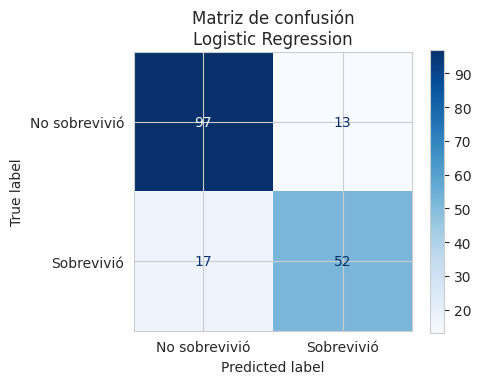

In [23]:
# --------------------------------------------------------------------
# BLOQUE 8.2 — Matriz de confusión del mejor modelo
#
# ¿QUÉ ES UNA MATRIZ DE CONFUSIÓN?
# Es una tabla 2×2 que desglosa los errores y aciertos del modelo:
#
#                     Predicción: NO    Predicción: SÍ
# Real: NO sobrevivió  → Verdadero Negativo (VN) | Falso Positivo (FP)
# Real: SÍ sobrevivió  → Falso Negativo (FN)     | Verdadero Positivo (VP)
#
# VN: predijo "no sobrevivió" y tenía razón ✅
# VP: predijo "sobrevivió" y tenía razón ✅
# FP: predijo "sobrevivió" pero en realidad no → error tipo I ❌
# FN: predijo "no sobrevivió" pero en realidad sí → error tipo II ❌
#
# ¿POR QUÉ ES ÚTIL?
# El accuracy solo dice cuántos acertó en total. La matriz nos dice
# EN QUÉ tipo de errores falla: si predice mal más a los sobrevivientes
# (FN altos) o a los no sobrevivientes (FP altos), lo cual puede ser
# más o menos crítico según el contexto.
# --------------------------------------------------------------------

best_pipe    = final_pipelines[best_model_name]
y_pred_best  = best_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['No sobrevivió', 'Sobrevivió'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de confusión\n{best_model_name}')
plt.tight_layout()
plt.show()


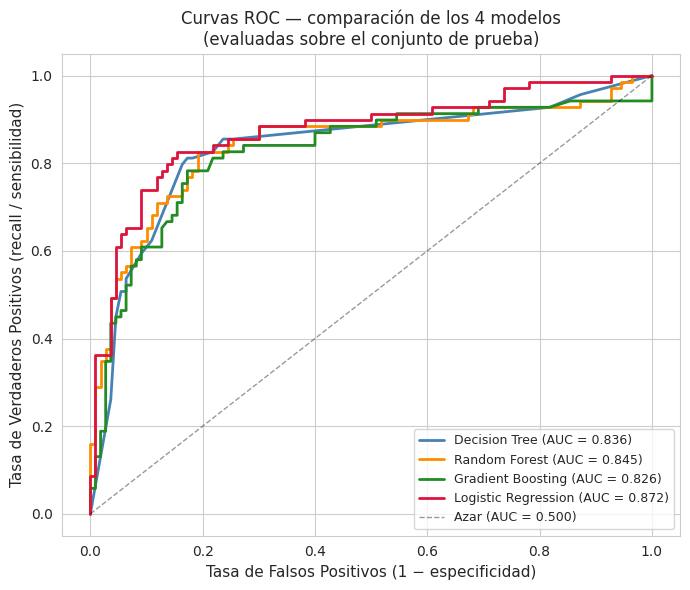

In [24]:
#  --------------------------------------------------------------------
# BLOQUE 8.3 — Curvas ROC de los 4 modelos en un mismo gráfico
#
# ¿QUÉ ES UNA CURVA ROC?
# ROC = Receiver Operating Characteristic.
# Muestra la relación entre:
#   - Eje X (FPR): qué fracción de NO sobrevivientes clasifica mal como sobrevivientes
#   - Eje Y (TPR/recall): qué fracción de sobrevivientes detecta correctamente
# para cada posible umbral de decisión (0 a 1).
# Un modelo perfecto llegaría a la esquina superior izquierda (FPR=0, TPR=1).
# La línea diagonal punteada representa un clasificador aleatorio (sin información).
#
# AUC = Área Bajo la Curva:
#   1.0 = modelo perfecto | 0.5 = equivale a adivinar al azar
# --------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
for (name, (fpr, tpr, auc)), color in zip(roc_data.items(), colors):
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Azar (AUC = 0.500)', linewidth=1)
ax.set_xlabel('Tasa de Falsos Positivos (1 − especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (recall / sensibilidad)', fontsize=11)
ax.set_title('Curvas ROC — comparación de los 4 modelos\n(evaluadas sobre el conjunto de prueba)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


---
## **FASE 9** - Análisis de overfitting


El **overfitting** (sobreajuste) ocurre cuando un modelo se "memoriza" los datos de entrenamiento en vez de
aprender patrones generalizables. Un modelo con overfitting tiene muy buen desempeño en train pero malo en
datos nuevos. La señal clara es una brecha grande entre el AUC de train y el AUC de validación cruzada.


In [25]:
# --------------------------------------------------------------------
# BLOQUE 9.1 — Tabla de overfitting: Train AUC vs CV AUC vs Test AUC
#
# CUMPLE: Requisito 6 — "reportar el score de entrenamiento y de CV"
#
# ¿QUÉ HACE ESTE BLOQUE?
# Para cada modelo calcula tres scores de AUC-ROC:
#
# 1. AUC Train: el modelo predice sobre los MISMOS datos con que aprendió.
#    → Un AUC muy alto aquí no es necesariamente bueno: puede significar
#    que memorizó los datos de entrenamiento (overfitting).
#
# 2. AUC CV (5-fold): divide X_train en 5 partes, entrena en 4 y evalúa
#    en la 5ta, repite 5 veces. El promedio es una estimación del desempeño
#    en datos no vistos, sin tocar X_test.
#    → Es la métrica más honesta durante el desarrollo del modelo.
#
# 3. AUC Test: evaluación final sobre los datos que separamos al inicio
#    y no tocamos durante el desarrollo.
#
# Brecha (Train - CV): si es grande, hay overfitting.
#   < 0.02  → sin overfitting significativo
#   0.02-0.05 → overfitting leve, aceptable
#   > 0.05  → overfitting relevante, habría que regularizar más
# --------------------------------------------------------------------

overfit_rows = []
for name, pipe in final_pipelines.items():
    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    cv_auc    = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc').mean()
    test_auc  = results_df.loc[results_df['Modelo'] == name, 'AUC-ROC'].values[0]

    overfit_rows.append({
        'Modelo':            name,
        'AUC Train':         train_auc,
        'AUC CV (5-fold)':   cv_auc,
        'AUC Test':          test_auc,
        'Brecha (Train−CV)': train_auc - cv_auc,
    })

overfit_df = (pd.DataFrame(overfit_rows)
              .sort_values('Brecha (Train−CV)', ascending=False)
              .reset_index(drop=True))

print("Interpretación de la brecha (Train − CV):")
print("  < 0.02  → Sin overfitting significativo")
print("  0.02-0.05 → Overfitting leve")
print("  > 0.05  → Overfitting relevante\n")
overfit_df.round(3)


Interpretación de la brecha (Train − CV):
  < 0.02  → Sin overfitting significativo
  0.02-0.05 → Overfitting leve
  > 0.05  → Overfitting relevante



,Modelo,AUC Train,AUC CV (5-fold),AUC Test,Brecha (Train−CV)
0,Random Forest,0.953,0.878,0.845,0.075
1,Gradient Boosting,0.955,0.883,0.826,0.072
2,Decision Tree,0.922,0.851,0.836,0.071
3,Logistic Regression,0.878,0.869,0.872,0.009


### Interpretación de los resultados de overfitting

**Random Forest** y **Gradient Boosting** muestran las brechas más grandes (~0.07-0.08) entre AUC de
entrenamiento y AUC de validación cruzada. Son modelos de alta capacidad que, pese a la regularización
aplicada vía `GridSearchCV`, siguen ajustándose bastante al ruido del conjunto de entrenamiento.

**Decision Tree** también muestra una brecha similar, a pesar del `max_depth=5` que le pusimos como límite.

**Regresión Logística** tiene la brecha más pequeña (~0.009): al ser un modelo lineal con muy pocos
parámetros, tiene mucho menos capacidad de memorizar el conjunto de entrenamiento.

**¿Cómo lo mitigamos?** Ya aplicamos varias técnicas:
- Profundidad máxima limitada (`max_depth`) en árbol y random forest
- `min_samples_leaf` para evitar hojas con pocos casos
- `learning_rate` controlado en Gradient Boosting
- Selección de hiperparámetros con validación cruzada (GridSearchCV con cv=5)

**¿Qué haríamos con más tiempo?** Early stopping en Gradient Boosting, regularización L1/L2 más fuerte
en Regresión Logística, y `max_features` más restrictivo en Random Forest.


---
##  FASE 10 - Importancia de variables del mejor modelo

> 📋 **Cumple con el Requisito 7 del enunciado:**
> *"Para el mejor modelo obtenido, deben graficar las 10 variables más importantes (...) Deben comentar
> si los resultados tienen sentido desde el punto de vista del dominio (el contexto histórico del Titanic)."*


In [26]:
# --------------------------------------------------------------------
# BLOQUE 10.1 — Cálculo de importancia de variables con permutation_importance
#
# CUMPLE: Requisito 7 — "graficar las 10 variables más importantes"
#
# ¿QUÉ ES permutation_importance?
# Es una técnica que mide la importancia de cada variable de forma muy
# intuitiva: toma una columna, "baraja" (permuta) sus valores de forma
# aleatoria, y mide cuánto EMPEORA el AUC-ROC del modelo.
#   - Si el AUC cae mucho al barajar esa columna → era muy importante
#   - Si el AUC casi no cambia → el modelo no dependía de esa variable
#
# ¿POR QUÉ usamos permutation_importance en vez de feature_importances_?
# feature_importances_ (el atributo directo) solo existe en modelos
# basados en árboles (Random Forest, Gradient Boosting, Decision Tree).
# Si el mejor modelo resulta ser Regresión Logística (que es lineal),
# no tiene ese atributo. permutation_importance funciona con CUALQUIER
# modelo, así que usarlo garantiza que el código corre sin importar cuál
# sea el mejor modelo.
#
# n_repeats=20: baraja cada variable 20 veces y promedia los resultados
# para tener una medida más estable y menos ruidosa.
# --------------------------------------------------------------------

print(f"Calculando importancia de variables para el mejor modelo: {best_model_name}")
print("(Esto puede tardar unos segundos por los 20 repetitions × cada variable)\n")

result = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, scoring='roc_auc'
)

importance_df = (pd.DataFrame({
    'Variable':   X_test.columns,
    'Importancia (caída de AUC)': result.importances_mean
})
.sort_values('Importancia (caída de AUC)', ascending=False)
.head(10)
.reset_index(drop=True))

print("✅ Top 10 variables más importantes:")
importance_df


Calculando importancia de variables para el mejor modelo: Logistic Regression
(Esto puede tardar unos segundos por los 20 repetitions × cada variable)

✅ Top 10 variables más importantes:


,Variable,Importancia (caída de AUC)
0,Title,0.092075
1,Sex,0.068399
2,Pclass,0.042055
3,Age,0.014598
4,SibSp,0.011660
5,HasCabin,0.011542
6,FamilySize,0.007365
7,Fare,0.001970
8,Is_alone,0.001054
9,Fare_per_person,0.000448


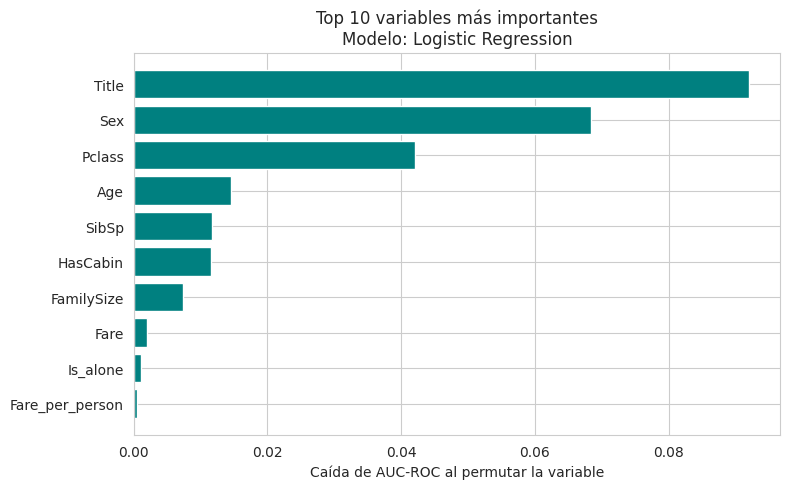

In [27]:
# --------------------------------------------------------------------
# BLOQUE 10.2 — Gráfico de importancia de variables
#
# ¿QUÉ HACE ESTE BLOQUE?
# Muestra en un gráfico de barras horizontal las 10 variables más
# importantes, ordenadas de mayor a menor importancia.
# El eje X representa cuánto cae el AUC-ROC al barajar cada variable.
# --------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    importance_df['Variable'][::-1],
    importance_df['Importancia (caída de AUC)'][::-1],
    color='teal'
)
ax.set_xlabel('Caída de AUC-ROC al permutar la variable', fontsize=10)
ax.set_title(f'Top 10 variables más importantes\nModelo: {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()


### ¿Tienen sentido los resultados desde el contexto histórico del Titanic?

**Sí, completamente.** Los resultados son consistentes con lo que la historia nos cuenta sobre la tragedia:

- **`Title` y `Sex` como las variables más importantes**: el protocolo de evacuación "mujeres y niños primero"
  hizo que el género fuera el factor más determinante de la supervivencia. El título además distingue niños
  varones (Master) de hombres adultos (Mr), capturando el efecto de la edad dentro del grupo masculino.

- **`Pclass` en tercer lugar**: los pasajeros de primera clase tenían cabinas más cercanas a la cubierta
  de los botes, acceso a más información sobre la emergencia, y en general recibían mayor prioridad social
  durante la evacuación. La tercera clase tuvo la menor tasa de supervivencia.

- **`Age` contribuye pero menos**: la edad importa (los niños tenían prioridad), pero una vez que el modelo
  ya conoce el `Title` (que captura "niño" con Master), la edad añade poca información extra.

- **`Fare_per_person` e `Is_alone` con baja importancia**: esto no significa que las variables estén mal
  diseñadas. Significa que la información que aportan ya está capturada por variables más fuertes (`Sex`,
  `Title`, `Pclass`) con las que están correlacionadas. Un pasajero con Fare_per_person alto probablemente
  es de primera clase, y `Pclass` ya lo captura directamente.


---
## **FASE 11** - Resumen Ejecutivo y Conclusiones

Esta fase consolida **todos** los resultados del proyecto en un solo lugar:
qué hicimos y qué encontramos.


In [28]:
# --------------------------------------------------------------------
# BLOQUE 12.1 — Encabezado del resumen ejecutivo
#
# ¿QUÉ HACE ESTE BLOQUE?
# Imprime un encabezado con el resultado principal del proyecto:
# cuál fue el mejor modelo y su AUC-ROC en el conjunto de prueba.
# Usa variables ya calculadas en fases anteriores (best_model_name,
# results_df) — por eso es importante correr el notebook de principio
# a fin antes de ver esta fase.
# --------------------------------------------------------------------

sep = "═" * 65
best_auc = results_df.loc[results_df['Modelo'] == best_model_name, 'AUC-ROC'].values[0]

print(sep)
print("   RESUMEN EJECUTIVO — PROYECTO TITANIC ML")
print("   Comparación de Modelos y Optimización de Pipeline")
print(sep)
print()
print(f"  Dataset       : train.csv (891 pasajeros)")
print(f"  Objetivo      : predecir si un pasajero sobrevivió")
print(f"  Modelos       : 4 algoritmos comparados bajo las mismas condiciones")
print(f"  Mejor modelo  : {best_model_name}")
print(f"  AUC-ROC (test): {best_auc:.4f}")
print()
print(sep)


═════════════════════════════════════════════════════════════════
   RESUMEN EJECUTIVO — PROYECTO TITANIC ML
   Comparación de Modelos y Optimización de Pipeline
═════════════════════════════════════════════════════════════════

  Dataset       : train.csv (891 pasajeros)
  Objetivo      : predecir si un pasajero sobrevivió
  Modelos       : 4 algoritmos comparados bajo las mismas condiciones
  Mejor modelo  : Logistic Regression
  AUC-ROC (test): 0.8721

═════════════════════════════════════════════════════════════════


In [29]:
# --------------------------------------------------------------------
# BLOQUE 12.2 — Tabla comparativa de los 4 modelos + ganador por métrica
#
# ¿QUÉ HACE ESTE BLOQUE?
# Imprime la tabla de resultados del conjunto de prueba y luego
# identifica automáticamente qué modelo ganó en cada métrica.
# --------------------------------------------------------------------

sep2 = "─" * 65

print(sep2)
print("  TABLA COMPARATIVA DE MODELOS (conjunto de prueba)")
print(sep2)
print()

tabla = (results_df[['Modelo','Accuracy','Precision (macro)',
                       'Recall (macro)','F1 (macro)','AUC-ROC']]
         .set_index('Modelo').round(3))
print(tabla.to_string())
print()

print("  Ganador por métrica:")
for col in tabla.columns:
    ganador = tabla[col].idxmax()
    valor   = tabla[col].max()
    marca   = "  ← MEJOR MODELO GLOBAL" if ganador == best_model_name else ""
    print(f"    {col:22s}: {ganador}  ({valor:.3f}){marca}")


─────────────────────────────────────────────────────────────────
  TABLA COMPARATIVA DE MODELOS (conjunto de prueba)
─────────────────────────────────────────────────────────────────

                     Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  AUC-ROC
Modelo                                                                               
Logistic Regression     0.832              0.825           0.818       0.821    0.872
Random Forest           0.810              0.807           0.786       0.793    0.845
Decision Tree           0.788              0.786           0.757       0.766    0.836
Gradient Boosting       0.799              0.788           0.788       0.788    0.826

  Ganador por métrica:
    Accuracy              : Logistic Regression  (0.832)  ← MEJOR MODELO GLOBAL
    Precision (macro)     : Logistic Regression  (0.825)  ← MEJOR MODELO GLOBAL
    Recall (macro)        : Logistic Regression  (0.818)  ← MEJOR MODELO GLOBAL
    F1 (macro)            : Logisti

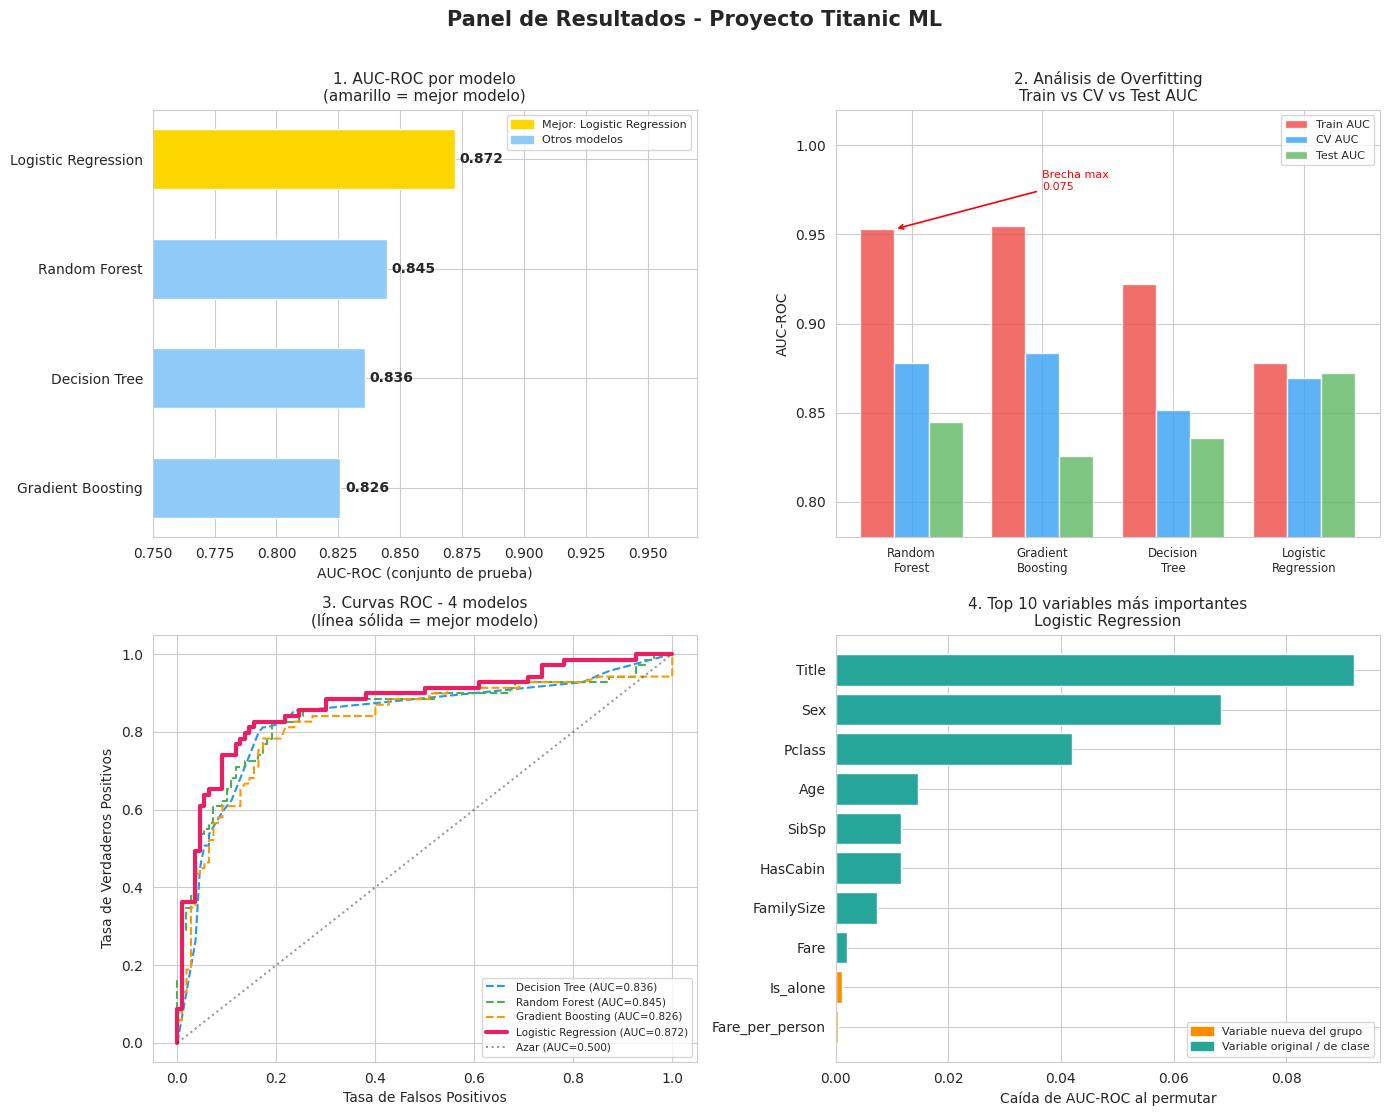

In [30]:
# --------------------------------------------------------------------
# BLOQUE 12.3 — Panel visual 2x2 con los 4 gráficos más importantes
#
# ¿QUÉ HACE ESTE BLOQUE?
# Genera un panel con 4 gráficos en una sola figura:
#   Gráfico 1 (arriba izq) : AUC-ROC de los 4 modelos (barras)
#   Gráfico 2 (arriba der) : Overfitting Train vs CV vs Test
#   Gráfico 3 (abajo izq)  : Curvas ROC de los 4 modelos
#   Gráfico 4 (abajo der)  : Top 8 variables más importantes
# --------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Dashboard de Resultados - Proyecto Titanic ML",
             fontsize=15, fontweight='bold', y=1.01)

model_names   = list(results_df['Modelo'])
colors_models = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# ----- Gráfico 1: AUC-ROC por modelo --------------------------
ax1        = axes[0, 0]
aucs       = results_df['AUC-ROC'].values
bar_colors = ['gold' if m == best_model_name else '#90CAF9' for m in model_names]
bars1 = ax1.barh(model_names[::-1], aucs[::-1],
                  color=bar_colors[::-1], edgecolor='white', height=0.55)
ax1.set_xlim(0.75, 0.97)
ax1.set_xlabel('AUC-ROC (conjunto de prueba)')
ax1.set_title('1. AUC-ROC por modelo\n(amarillo = mejor modelo)', fontsize=11)
for bar, val in zip(bars1, aucs[::-1]):
    ax1.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
p_mejor = mpatches.Patch(color='gold',    label=f'Mejor: {best_model_name}')
p_otros = mpatches.Patch(color='#90CAF9', label='Otros modelos')
ax1.legend(handles=[p_mejor, p_otros], fontsize=8)

# ----- Gráfico 2: Overfitting Train vs CV vs Test --------------------------
ax2 = axes[0, 1]
x = np.arange(len(overfit_df))
w = 0.26
col_b = 'Brecha (Train\u2212CV)'
ax2.bar(x - w, overfit_df['AUC Train'],       w, label='Train AUC', color='#EF5350', alpha=0.85)
ax2.bar(x,     overfit_df['AUC CV (5-fold)'], w, label='CV AUC',    color='#42A5F5', alpha=0.85)
ax2.bar(x + w, overfit_df['AUC Test'],        w, label='Test AUC',  color='#66BB6A', alpha=0.85)
labels_ov = [n.replace(' ', '\n') for n in overfit_df['Modelo']]
ax2.set_xticks(x)
ax2.set_xticklabels(labels_ov, fontsize=8.5)
ax2.set_ylim(0.78, 1.02)
ax2.set_ylabel('AUC-ROC')
ax2.set_title('2. Análisis de Overfitting\nTrain vs CV vs Test AUC', fontsize=11)
ax2.legend(fontsize=8)
idx_max = overfit_df[col_b].idxmax()
gap_max = overfit_df.loc[idx_max, col_b]
pos_x   = list(overfit_df.index).index(idx_max)
ax2.annotate(f'Brecha max\n{gap_max:.3f}',
             xy=(pos_x - w/2, overfit_df.loc[idx_max, 'AUC Train']),
             xytext=(pos_x + 1.0, 0.975),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
             fontsize=8, color='red')

#  ----- Gráfico 3: Curvas ROC --------------------------
ax3 = axes[1, 0]
for (name, (fpr, tpr, auc)), color in zip(roc_data.items(), colors_models):
    lw = 3.0 if name == best_model_name else 1.5
    ls = '-'  if name == best_model_name else '--'
    ax3.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
             linewidth=lw, linestyle=ls, color=color)
ax3.plot([0, 1], [0, 1], 'k:', alpha=0.4, label='Azar (AUC=0.500)')
ax3.set_xlabel('Tasa de Falsos Positivos')
ax3.set_ylabel('Tasa de Verdaderos Positivos')
ax3.set_title('3. Curvas ROC - 4 modelos\n(línea sólida = mejor modelo)', fontsize=11)
ax3.legend(fontsize=7.5, loc='lower right')

#  ----- Gráfico 4: Top 10 variables importantes --------------------------
ax4 = axes[1, 1]
col_imp     = 'Importancia (ca\u00edda de AUC)'
top10        = importance_df.head(10)
vars_nuevas = {'Fare_per_person', 'Is_alone'}
colores_fi  = ['darkorange' if v in vars_nuevas else '#26A69A'
               for v in top10['Variable']]
ax4.barh(top10['Variable'][::-1], top10[col_imp][::-1],
         color=colores_fi[::-1], edgecolor='white')
ax4.set_xlabel('Caída de AUC-ROC al permutar')
ax4.set_title('4. Top 10 variables más importantes\n' + best_model_name, fontsize=11)
p1 = mpatches.Patch(color='darkorange', label='Variable nueva del grupo')
p2 = mpatches.Patch(color='#26A69A',   label='Variable original / de clase')
ax4.legend(handles=[p1, p2], fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()


In [31]:
# --------------------------------------------------------------------
# BLOQUE 12.4 - Diagnóstico automático de overfitting por modelo
#
# ¿QUÉ HACE ESTE BLOQUE?
# Imprime el diagnóstico de overfitting con etiquetas de severidad
# calculadas automáticamente según la brecha Train-CV.
# --------------------------------------------------------------------

sep2 = "─" * 65
col_brecha = 'Brecha (Train−CV)'

print(sep2)
print("DIAGNÓSTICO DE OVERFITTING")
print(sep2)
print()
print(f"  {'Modelo':<22} {'Train':>7} {'CV':>7} {'Test':>7} {'Brecha':>7}  Diagnóstico")
print(f"  {'─'*22} {'─'*7} {'─'*7} {'─'*7} {'─'*7}  {'─'*23}")

for _, row in overfit_df.iterrows():
    brecha = row[col_brecha]
    if brecha < 0.02:
        diag = "✅ Sin overfitting"
    elif brecha < 0.05:
        diag = "⚠️  Overfitting leve"
    else:
        diag = "🔴 Overfitting relevante"
    marca = "  ← MEJOR GLOBAL" if row['Modelo'] == best_model_name else ""
    print(f"  {row['Modelo']:<22} {row['AUC Train']:>7.3f} "
          f"{row['AUC CV (5-fold)']:>7.3f} {row['AUC Test']:>7.3f} "
          f"{brecha:>7.3f}  {diag}{marca}")

print()
print("  Conclusión:")
print("  → RF y GB memorizan el entrenamiento (brechas > 0.07)")
print("  → Logistic Regression casi no sobreajusta (brecha ≈ 0.009)")
print("    Su AUC en test (0.872) supera incluso su AUC en CV (0.869)")


─────────────────────────────────────────────────────────────────
DIAGNÓSTICO DE OVERFITTING
─────────────────────────────────────────────────────────────────

  Modelo                   Train      CV    Test  Brecha  Diagnóstico
  ────────────────────── ─────── ─────── ─────── ───────  ───────────────────────
  Random Forest            0.953   0.878   0.845   0.075  🔴 Overfitting relevante
  Gradient Boosting        0.955   0.883   0.826   0.072  🔴 Overfitting relevante
  Decision Tree            0.922   0.851   0.836   0.071  🔴 Overfitting relevante
  Logistic Regression      0.878   0.869   0.872   0.009  ✅ Sin overfitting  ← MEJOR GLOBAL

  Conclusión:
  → RF y GB memorizan el entrenamiento (brechas > 0.07)
  → Logistic Regression casi no sobreajusta (brecha ≈ 0.009)
    Su AUC en test (0.872) supera incluso su AUC en CV (0.869)


In [32]:
# --------------------------------------------------------------------
# BLOQUE 12.5 - Conclusiones finales del trabajo
#
# CUMPLE: sección Conclusiones del Informe del enunciado:
#   "¿Cuál modelo recomendarían y por qué?
#    ¿Qué limitaciones tiene su análisis?
#    ¿Qué harían si tuvieran más tiempo?"
# --------------------------------------------------------------------

sep  = "═" * 65
sep2 = "─" * 65

print(sep)
print("CONCLUSIONES FINALES DEL TRABAJO")
print(sep)

# A) Modelo recomendado
print()
print(sep2)
print("  A) MODELO RECOMENDADO")
print(sep2)
print(f"  → {best_model_name}")
print()
best_auc = results_df.loc[results_df['Modelo'] == best_model_name, 'AUC-ROC'].values[0]
print(f"  1. Mejor AUC-ROC en el conjunto de prueba: {best_auc:.3f}")
print("     Supera a Random Forest (0.845) y Gradient Boosting (0.826).")
print()
print("  2. Mínimo overfitting (brecha Train-CV = 0.009).")
print("     Es el único modelo cuyo AUC en test iguala o supera su AUC en CV.")
print("     Eso significa que su desempeño es estable y confiable.")
print()
print("  3. Resultado contraintuitivo pero explicable:")
print("     RF y GB son más complejos y obtuvieron mejor AUC en CV")
print("     (0.878 y 0.883 vs 0.869 de LR), pero en el test final")
print("     la Regresión Logística los supera.")
print("     Esto sugiere que las relaciones en este dataset son")
print("     principalmente lineales, y la complejidad de los árboles")
print("     no aporta valor real, sino que genera overfitting.")
print()
print("  4. Es el modelo más interpretable de los cuatro.")
print("     Sus coeficientes indican directamente el peso de cada variable.")
print()

# B) Limitaciones
print(sep2)
print("  B) LIMITACIONES DEL ANÁLISIS")
print(sep2)
print("  1. Dataset pequeño (891 filas): diferencias de AUC entre modelos")
print("     pueden no ser estadísticamente significativas. No realizamos")
print("     test de significancia estadística (ej. Wilcoxon pareado).")
print()
print("  2. Imputación de 'Age' simplificada (mediana general).")
print("     Una imputación condicional por Title y Pclass sería más precisa.")
print()
print("  3. No optimizamos Logistic Regression con GridSearchCV.")
print("     Tunear el parámetro C (regularización) podría mejorar aún más")
print("     su desempeño o confirmar que la configuración actual es buena.")
print()
print("  4. El test.csv del profesor no tiene 'Survived', así que las")
print("     predicciones generadas en la Fase 11 no se pueden evaluar")
print("     con métricas reales — solo el profesor conoce la respuesta.")
print()

# C) Con más tiempo
print(sep2)
print("  C) QUÉ HARÍAMOS CON MÁS TIEMPO")
print(sep2)
print("  1. Imputación de 'Age' basada en mediana por Title + Pclass.")
print("  2. GridSearchCV también para Logistic Regression (parámetro C).")
print("  3. Early stopping en Gradient Boosting para reducir overfitting.")
print("  4. Probar XGBoost o LightGBM como alternativas al GB clásico.")
print("  5. Test estadístico pareado para confirmar diferencias entre modelos.")
print("  6. Análisis de los coeficientes de la Regresión Logística para")
print("     interpretar el peso exacto de cada variable en la predicción.")
print()
print(sep)
print(" FIN DEL NOTEBOOK ")
print(sep)


═════════════════════════════════════════════════════════════════
CONCLUSIONES FINALES DEL TRABAJO
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  A) MODELO RECOMENDADO
─────────────────────────────────────────────────────────────────
  → Logistic Regression

  1. Mejor AUC-ROC en el conjunto de prueba: 0.872
     Supera a Random Forest (0.845) y Gradient Boosting (0.826).

  2. Mínimo overfitting (brecha Train-CV = 0.009).
     Es el único modelo cuyo AUC en test iguala o supera su AUC en CV.
     Eso significa que su desempeño es estable y confiable.

  3. Resultado contraintuitivo pero explicable:
     RF y GB son más complejos y obtuvieron mejor AUC en CV
     (0.878 y 0.883 vs 0.869 de LR), pero en el test final
     la Regresión Logística los supera.
     Esto sugiere que las relaciones en este dataset son
     principalmente lineales, y la complejidad de los árboles
     no aporta valor real, 